# 📘 Clase 6 - Distribuciones y Detección de Outliers con Seaborn

## 🧾 Dataset

Trabajaremos con un conjunto de datos de una aseguradora que contiene información sobre clientes, sus características personales, tipos de pólizas y montos reclamados.

### 📋 Campos destacados:
- **CustomerLifetimeValue**: Valor estimado del cliente para la empresa.
- **ClaimAmount**: Monto reclamado por el cliente.
- **Coverage**: Tipo de cobertura contratada.
- **PolicyType** y **Policy**: Detalles del tipo de póliza.
- **VehicleClass** y **VehicleSize**: Tipo y tamaño del vehículo asegurado.
- **EmploymentStatus**, **Education**, **Gender**, etc.: Información demográfica.

Este dataset será usado para analizar distribuciones, detectar valores atípicos (outliers) y aplicar conceptos como asimetría y curtosis.

---


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore, skew, kurtosis

# Cargar datos
df = pd.read_csv("customer.csv")

# Vista previa
df.head()


,Unnamed: 0,Customer,State,CustomerLifetimeValue,Response,Coverage,Education,EffectiveToDate,EmploymentStatus,Gender,...,MonthsSincePolicyInception,NumberofOpenComplaints,NumberofPolicies,PolicyType,Policy,RenewOfferType,SalesChannel,ClaimAmount,VehicleClass,VehicleSize
0,0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


### 📊 Ejercicio 1: Histograma y Curva de Densidad

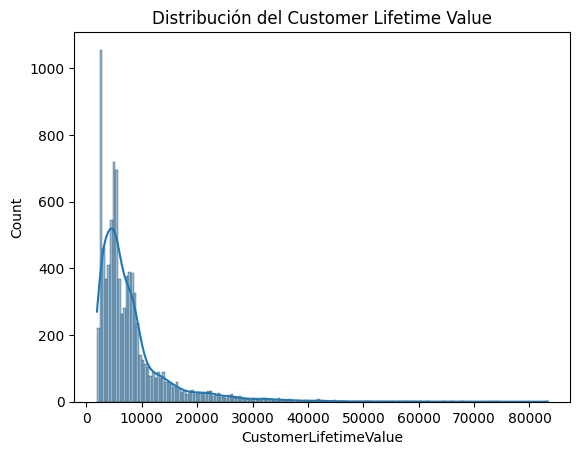

In [3]:
sns.histplot(df["CustomerLifetimeValue"], kde=True)
plt.title("Distribución del Customer Lifetime Value")
plt.show()


### 📦 Ejercicio 2: Detección de Outliers con Boxplot

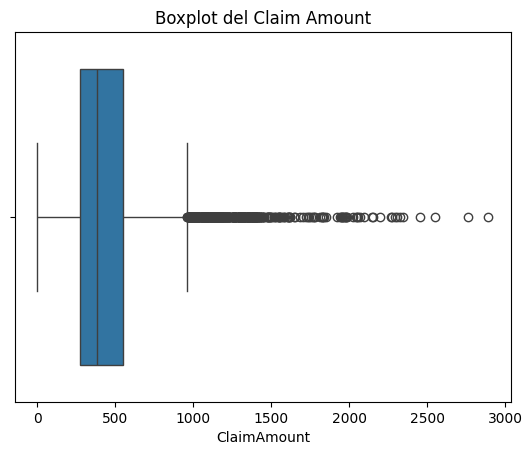

In [4]:
sns.boxplot(x=df["ClaimAmount"])
plt.title("Boxplot del Claim Amount")
plt.show()


### 🧮 Ejercicio 3: Detección de Outliers con IQR

In [5]:
Q1 = df["CustomerLifetimeValue"].quantile(0.25)
Q3 = df["CustomerLifetimeValue"].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = df[(df["CustomerLifetimeValue"] < Q1 - 1.5 * IQR) | 
                  (df["CustomerLifetimeValue"] > Q3 + 1.5 * IQR)]

print(f"Cantidad de outliers detectados por IQR: {outliers_iqr.shape[0]}")


Cantidad de outliers detectados por IQR: 817


### 🧠 Ejercicio 4: Detección de Outliers con Z-score

In [6]:
z_scores = zscore(df["ClaimAmount"])
outliers_z = df[np.abs(z_scores) > 3]

print(f"Cantidad de outliers detectados por Z-score: {outliers_z.shape[0]}")


Cantidad de outliers detectados por Z-score: 158


### 📈 Ejercicio 5: Boxplot por cobertura

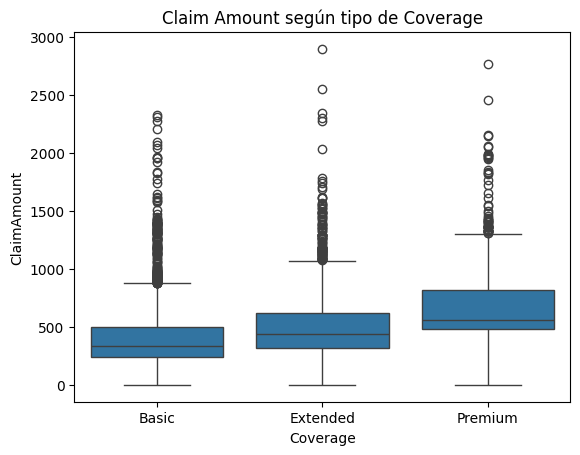

In [7]:
sns.boxplot(x="Coverage", y="ClaimAmount", data=df)
plt.title("Claim Amount según tipo de Coverage")
plt.show()


### 🎻 Ejercicio 6: Violinplot por clase de vehículo

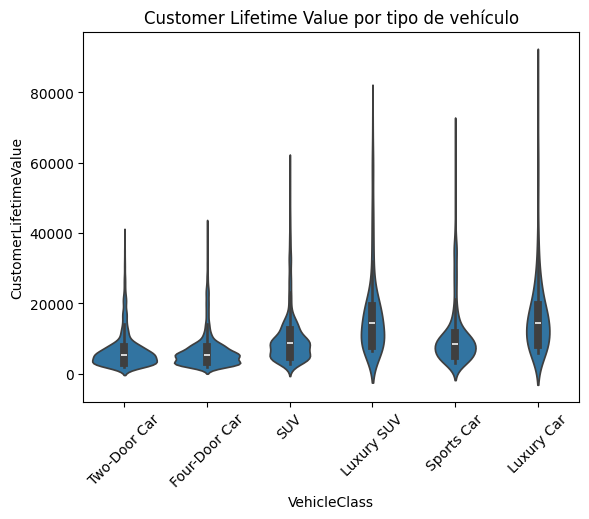

In [8]:
sns.violinplot(x="VehicleClass", y="CustomerLifetimeValue", data=df)
plt.xticks(rotation=45)
plt.title("Customer Lifetime Value por tipo de vehículo")
plt.show()


### 🔀 Ejercicio 7: Asimetría

In [9]:
skew_clv = skew(df["CustomerLifetimeValue"].dropna())
print(f"Asimetría (CustomerLifetimeValue): {skew_clv}")


Asimetría (CustomerLifetimeValue): 3.031782271327885


### ⛰️ Ejercicio 8: Curtosis

In [10]:
kurt_clv = kurtosis(df["CustomerLifetimeValue"].dropna())
print(f"Curtosis (CustomerLifetimeValue): {kurt_clv}")


Curtosis (CustomerLifetimeValue): 13.815310695287437


## 📝 Parte final: Actividades para resolver

1. ¿Cuál es el tipo de distribución que presenta `ClaimAmount`?
2. Identificá si hay outliers en `CustomerLifetimeValue` usando visualización.
3. Usá el método del IQR para detectar outliers en `MonthlyPremiumAuto`.
4. Usá el método del Z-score en `TotalClaimAmount` y reportá cuántos outliers hay.
5. Compará `ClaimAmount` según `Education` con un boxplot.
6. ¿Qué diferencias ves entre `VehicleSize` y `CustomerLifetimeValue`?
7. Calculá y analizá la asimetría de `MonthlyPremiumAuto`.
8. ¿Qué indica la curtosis de `TotalClaimAmount`?
9. Usá un `pairplot` con variables numéricas del dataset.
10. ¿Cómo puede afectar la presencia de outliers en un modelo predictivo?

